In [1]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.stats import norm
import time

HESTON MODEL — FULL PIPELINE

Parameters:
  S0=100, r=0.03, v0=0.04, theta=0.04
  kappa=2.0, xi=0.5, rho=-0.7
  Feller condition 2*kappa*theta=0.160 vs xi^2=0.250 -> VIOLATED

1. FOURIER PRICING vs MONTE CARLO

Fourier pricing (T=0.5)...
Monte Carlo pricing (200000 paths)...

Fourier time: 0.021s | MC time: 5.351s

  Strike    Fourier         MC       Diff
------------------------------------------
    80.0    21.8622    21.8548     0.0074
    85.0    17.4031    17.3948     0.0083
    90.0    13.2023    13.1946     0.0077
    95.0     9.3711     9.3646     0.0065
   100.0     6.0554     6.0487     0.0067
   105.0     3.4290     3.4244     0.0047
   110.0     1.6371     1.6359     0.0012
   115.0     0.6569     0.6569    -0.0000
   120.0     0.2347     0.2353    -0.0005

2. IMPLIED VOLATILITY SMILE

3. PARAMETER SENSITIVITY
Saved: heston_smiles.png
Saved: heston_params.png

4. VOLATILITY SURFACE
Saved: heston_surface.png

5. SYNTHETIC CALIBRATION TEST
True params: v0=0.04, theta=0.04, k

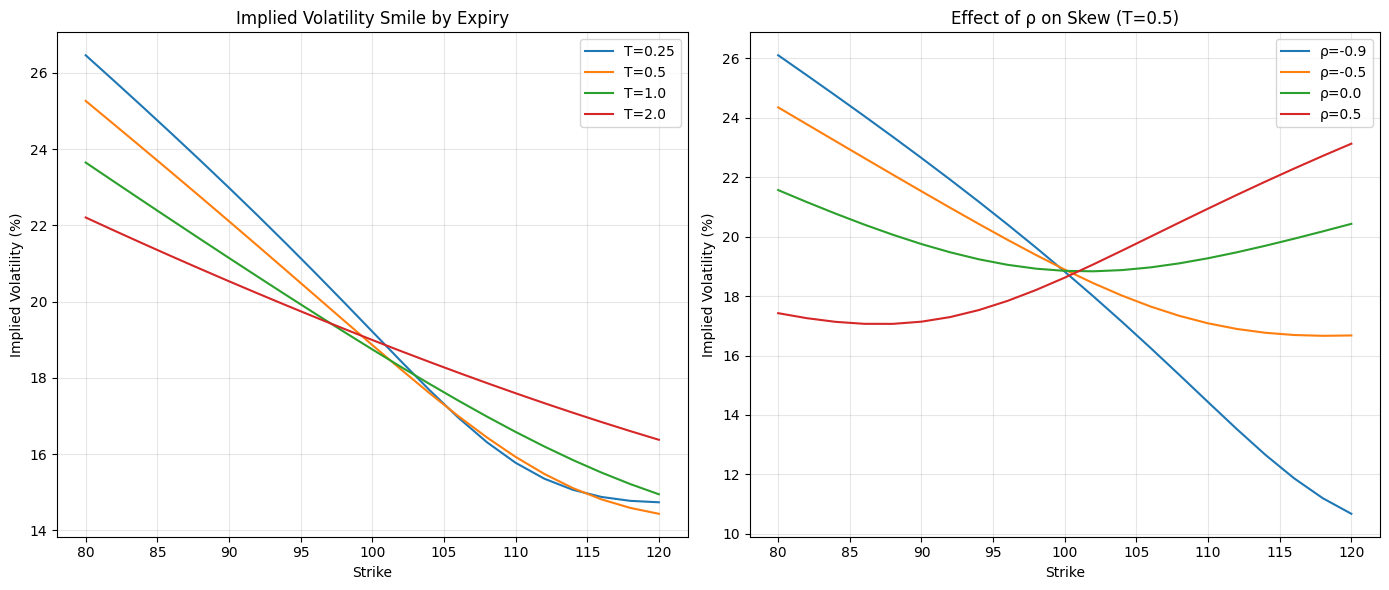

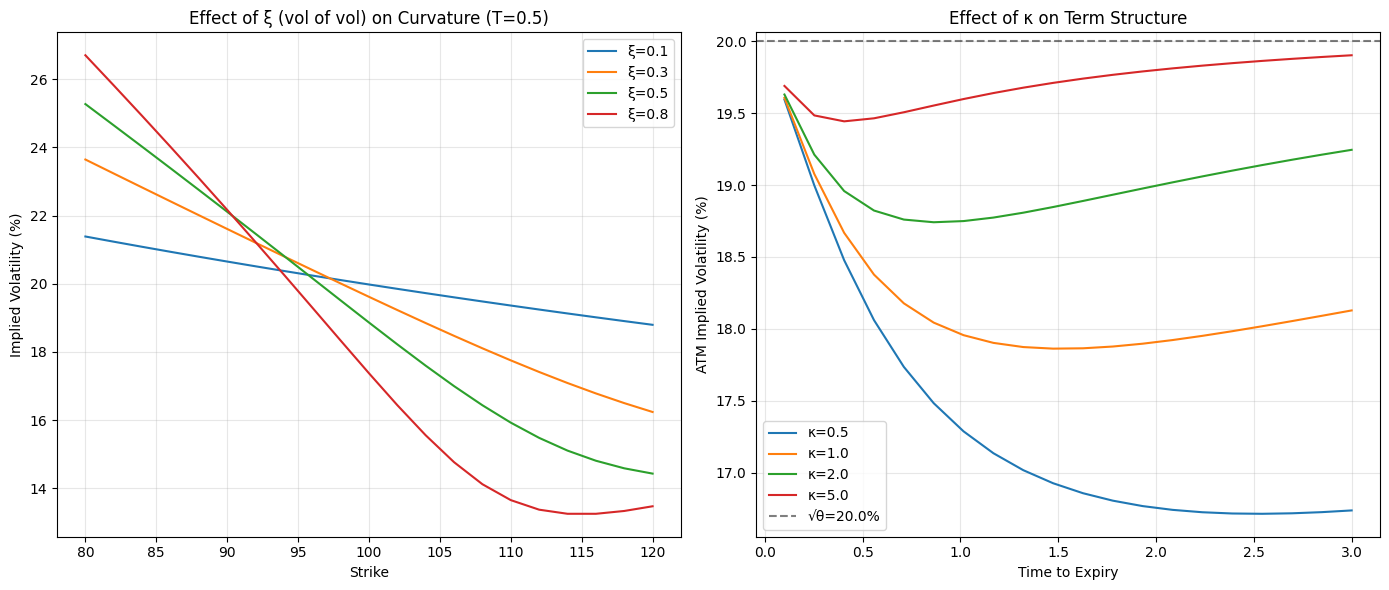

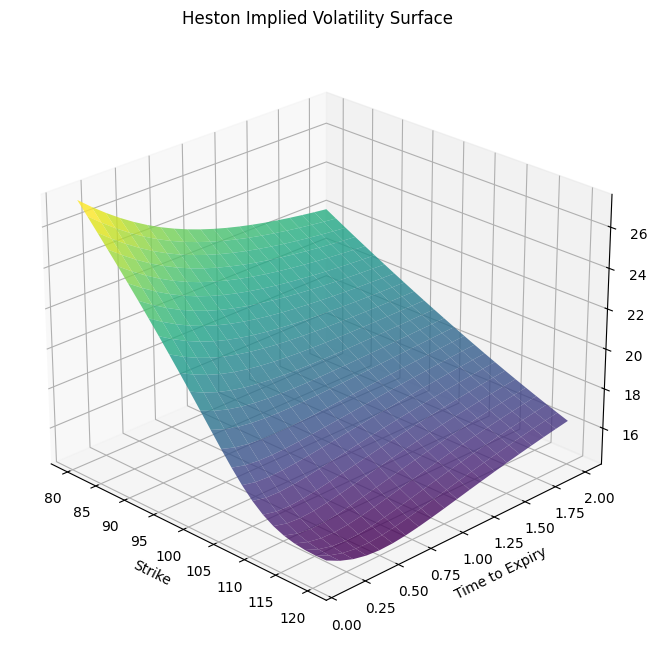

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.stats import norm
import time


def heston_char_func_j(omega, v0, theta, kappa, xi, rho, r, T, x0, j):
    if j == 1:
        u = 0.5
        b = kappa - rho * xi
    else:
        u = -0.5
        b = kappa

    d = np.sqrt((rho * xi * 1j * omega - b)**2 - xi**2 * (2 * u * 1j * omega - omega**2))
    g = (b - rho * xi * 1j * omega - d) / (b - rho * xi * 1j * omega + d)

    D = (b - rho * xi * 1j * omega - d) / xi**2 * (1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T))
    C = r * 1j * omega * T + kappa * theta / xi**2 * (
        (b - rho * xi * 1j * omega - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))
    )

    return np.exp(C + D * v0 + 1j * omega * x0)


def heston_call_price(S0, K, r, T, v0, theta, kappa, xi, rho):
    x0 = np.log(S0)
    lnK = np.log(K)

    def integrand_j(omega, j):
        phi = heston_char_func_j(omega, v0, theta, kappa, xi, rho, r, T, x0, j)
        return np.real(np.exp(-1j * omega * lnK) * phi / (1j * omega))

    I1, _ = quad(lambda w: integrand_j(w, 1), 1e-8, 200, limit=200)
    I2, _ = quad(lambda w: integrand_j(w, 2), 1e-8, 200, limit=200)

    P1 = 0.5 + I1 / np.pi
    P2 = 0.5 + I2 / np.pi

    return S0 * P1 - K * np.exp(-r * T) * P2


def bs_call_price(S0, K, r, T, sigma):
    d1 = (np.log(S0 / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def heston_implied_vol(S0, K, r, T, v0, theta, kappa, xi, rho):
    price = heston_call_price(S0, K, r, T, v0, theta, kappa, xi, rho)
    lo, hi = 1e-4, 5.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if bs_call_price(S0, K, r, T, mid) > price:
            hi = mid
        else:
            lo = mid
    return mid


def heston_monte_carlo(S0, r, T, v0, theta, kappa, xi, rho, K_array, n_paths=200000, n_steps=500):
    dt = T / n_steps
    S = np.full(n_paths, S0, dtype=np.float64)
    v = np.full(n_paths, v0, dtype=np.float64)

    for _ in range(n_steps):
        Z1 = np.random.standard_normal(n_paths)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(n_paths)

        v_pos = np.maximum(v, 0)
        S = S * np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * Z1)
        v = v + kappa * (theta - v_pos) * dt + xi * np.sqrt(v_pos * dt) * Z2

    prices = []
    for K in K_array:
        payoff = np.maximum(S - K, 0)
        prices.append(np.exp(-r * T) * np.mean(payoff))

    return np.array(prices)


def calibrate_heston(S0, r, market_strikes, market_expiries, market_iv):
    def objective(params):
        v0, theta, kappa, xi, rho = params
        total_err = 0
        for i in range(len(market_strikes)):
            K = market_strikes[i]
            T = market_expiries[i]
            iv_target = market_iv[i]
            try:
                iv_model = heston_implied_vol(S0, K, r, T, v0, theta, kappa, xi, rho)
                total_err += (iv_model - iv_target)**2
            except:
                total_err += 1.0
        return total_err

    bounds = [(0.001, 1.0), (0.001, 1.0), (0.1, 10.0), (0.01, 2.0), (-0.99, 0.99)]
    x0 = [0.04, 0.04, 1.5, 0.4, -0.7]
    result = minimize(objective, x0, bounds=bounds, method='L-BFGS-B')
    return result.x, result.fun


if __name__ == "__main__":
    S0 = 100
    r = 0.03
    v0 = 0.04
    theta = 0.04
    kappa = 2.0
    xi = 0.5
    rho = -0.7

    print("=" * 60)
    print("HESTON MODEL — FULL PIPELINE")
    print("=" * 60)
    print(f"\nParameters:")
    print(f"  S0={S0}, r={r}, v0={v0}, theta={theta}")
    print(f"  kappa={kappa}, xi={xi}, rho={rho}")
    print(f"  Feller condition 2*kappa*theta={2*kappa*theta:.3f} vs xi^2={xi**2:.3f}",
          "-> SATISFIED" if 2*kappa*theta >= xi**2 else "-> VIOLATED")

    print("\n" + "=" * 60)
    print("1. FOURIER PRICING vs MONTE CARLO")
    print("=" * 60)

    T = 0.5
    strikes = np.linspace(80, 120, 9)

    print(f"\nFourier pricing (T={T})...")
    t0 = time.time()
    fourier_prices = [heston_call_price(S0, K, r, T, v0, theta, kappa, xi, rho) for K in strikes]
    t_fourier = time.time() - t0

    print(f"Monte Carlo pricing ({200000} paths)...")
    t0 = time.time()
    mc_prices = heston_monte_carlo(S0, r, T, v0, theta, kappa, xi, rho, strikes)
    t_mc = time.time() - t0

    print(f"\nFourier time: {t_fourier:.3f}s | MC time: {t_mc:.3f}s")
    print(f"\n{'Strike':>8} {'Fourier':>10} {'MC':>10} {'Diff':>10}")
    print("-" * 42)
    for i, K in enumerate(strikes):
        print(f"{K:8.1f} {fourier_prices[i]:10.4f} {mc_prices[i]:10.4f} {fourier_prices[i]-mc_prices[i]:10.4f}")

    print("\n" + "=" * 60)
    print("2. IMPLIED VOLATILITY SMILE")
    print("=" * 60)

    smile_strikes = np.linspace(80, 120, 21)
    expiries = [0.25, 0.5, 1.0, 2.0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for T_val in expiries:
        ivs = [heston_implied_vol(S0, K, r, T_val, v0, theta, kappa, xi, rho) for K in smile_strikes]
        axes[0].plot(smile_strikes, np.array(ivs) * 100, label=f'T={T_val}')

    axes[0].set_xlabel('Strike')
    axes[0].set_ylabel('Implied Volatility (%)')
    axes[0].set_title('Implied Volatility Smile by Expiry')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    print("\n" + "=" * 60)
    print("3. PARAMETER SENSITIVITY")
    print("=" * 60)

    T_sens = 0.5
    rhos = [-0.9, -0.5, 0.0, 0.5]
    for rho_val in rhos:
        ivs = [heston_implied_vol(S0, K, r, T_sens, v0, theta, kappa, xi, rho_val) for K in smile_strikes]
        axes[1].plot(smile_strikes, np.array(ivs) * 100, label=f'ρ={rho_val}')

    axes[1].set_xlabel('Strike')
    axes[1].set_ylabel('Implied Volatility (%)')
    axes[1].set_title(f'Effect of ρ on Skew (T={T_sens})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('heston_smiles.png', dpi=150, bbox_inches='tight')
    print("Saved: heston_smiles.png")

    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

    xis = [0.1, 0.3, 0.5, 0.8]
    for xi_val in xis:
        ivs = [heston_implied_vol(S0, K, r, T_sens, v0, theta, kappa, xi_val, rho) for K in smile_strikes]
        axes2[0].plot(smile_strikes, np.array(ivs) * 100, label=f'ξ={xi_val}')

    axes2[0].set_xlabel('Strike')
    axes2[0].set_ylabel('Implied Volatility (%)')
    axes2[0].set_title(f'Effect of ξ (vol of vol) on Curvature (T={T_sens})')
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3)

    kappas = [0.5, 1.0, 2.0, 5.0]
    T_term = np.linspace(0.1, 3.0, 20)
    for kappa_val in kappas:
        atm_ivs = [heston_implied_vol(S0, S0, r, T_val, v0, theta, kappa_val, xi, rho) for T_val in T_term]
        axes2[1].plot(T_term, np.array(atm_ivs) * 100, label=f'κ={kappa_val}')

    axes2[1].axhline(y=np.sqrt(theta) * 100, color='k', linestyle='--', alpha=0.5, label=f'√θ={np.sqrt(theta)*100:.1f}%')
    axes2[1].set_xlabel('Time to Expiry')
    axes2[1].set_ylabel('ATM Implied Volatility (%)')
    axes2[1].set_title('Effect of κ on Term Structure')
    axes2[1].legend()
    axes2[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('heston_params.png', dpi=150, bbox_inches='tight')
    print("Saved: heston_params.png")

    print("\n" + "=" * 60)
    print("4. VOLATILITY SURFACE")
    print("=" * 60)

    surf_strikes = np.linspace(80, 120, 25)
    surf_expiries = np.linspace(0.1, 2.0, 20)
    K_grid, T_grid = np.meshgrid(surf_strikes, surf_expiries)
    IV_grid = np.zeros_like(K_grid)

    for i in range(K_grid.shape[0]):
        for j in range(K_grid.shape[1]):
            IV_grid[i, j] = heston_implied_vol(S0, K_grid[i, j], r, T_grid[i, j], v0, theta, kappa, xi, rho) * 100

    fig3 = plt.figure(figsize=(12, 8))
    ax3 = fig3.add_subplot(111, projection='3d')
    ax3.plot_surface(K_grid, T_grid, IV_grid, cmap='viridis', alpha=0.8)
    ax3.set_xlabel('Strike')
    ax3.set_ylabel('Time to Expiry')
    ax3.set_zlabel('Implied Vol (%)')
    ax3.set_title('Heston Implied Volatility Surface')
    ax3.view_init(elev=25, azim=-45)
    plt.savefig('heston_surface.png', dpi=150, bbox_inches='tight')
    print("Saved: heston_surface.png")

    print("\n" + "=" * 60)
    print("5. SYNTHETIC CALIBRATION TEST")
    print("=" * 60)

    true_params = (v0, theta, kappa, xi, rho)
    print(f"True params: v0={v0}, theta={theta}, kappa={kappa}, xi={xi}, rho={rho}")

    cal_strikes = np.array([85, 90, 95, 100, 105, 110, 115])
    cal_expiries = np.array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
                             0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
                             1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
    cal_K = np.tile(cal_strikes, 3)

    market_iv = []
    for i in range(len(cal_K)):
        iv = heston_implied_vol(S0, cal_K[i], r, cal_expiries[i], v0, theta, kappa, xi, rho)
        market_iv.append(iv + np.random.normal(0, 0.002))
    market_iv = np.array(market_iv)

    print("Calibrating...")
    t0 = time.time()
    fitted_params, fit_err = calibrate_heston(S0, r, cal_K, cal_expiries, market_iv)
    t_cal = time.time() - t0

    print(f"Calibration time: {t_cal:.1f}s")
    print(f"\n{'Param':>8} {'True':>10} {'Fitted':>10}")
    print("-" * 32)
    names = ['v0', 'theta', 'kappa', 'xi', 'rho']
    for name, true, fitted in zip(names, true_params, fitted_params):
        print(f"{name:>8} {true:10.4f} {fitted:10.4f}")

    print(f"\nTotal squared IV error: {fit_err:.6f}")

    print("\n" + "=" * 60)
    print("DONE")
    print("=" * 60)